# Introduction

Citibike is the leading bikesharing platform in New York, including the districts of Manhattan, Brooklyn, Queens & Jersey City. That said, the company is far from being profitable due to growing competition from other modes of transportation (e.g., scooters, electric bikes, etc.). According to a consulting firm hired a few months ago, the operations of Citibike are inefficient due to the lack of data-driven decision processes. If Citibike were only 4\% more efficient, it would become profitable. During peak hours (e.g., morning commute time), the bikesharing platform is particularly unreliable. Approximately 20\% of the dock stations face a "stock-out" situation, meaning that there are no bikes available. In such cases, commuters choose other modes of transportation. 

<img src="citi-bike.jpg" width="500">

### Goal
The consulting firm recommends using **optimization models** to improve the operations, especially during peak time. As part of this new strategy, we are recently hired as a lead data scientist of Citibike. We suspect that the inventory of bikes and the dock stations are not well positioned given the incoming demand at peak times. We will develop a data-driven optimization model to improve the positioning of inventory at peak time. In particular, we will formulate and implement integer programming models.




#  Visualize the data 

## Load the data

Our colleague has generated data sets that contains all the needed information about the demand and available inventory of bikes during *one hour at peak time*. Your initial analysis will be based on the following data sets:

- `demand.csv`: describes the number of bikes rented at each dock station (during one peak hour),
- `starting_inventory.csv`: describes the initial inventory of bikes at each dock station (before peak hour),
- `distances.csv`: describes the distance between any two dock stations (in km unit).


Ideally, the inventory of bikes available the beginning of the peak hour should approximately match the expected amount of demand. For example, if you expect 5 user requests in station A, and 5 user requests in station B in the next hour, the number of bikes in station A and B should be roughly equal, otherwise there is an imbalance of inventory. Using spatial visualization, you will check if the initial inventory is balanced or imbalanced.

*Execute the cells below. Read carefully all the comments*

In [1]:
# Import various packages
import pandas as pd
import numpy as np
import folium # visualisation package for spatial data (plot of maps)
import seaborn as sns # general visualization package 
import matplotlib.pyplot as plt # general visualization package 
#next command allows you to display the figures in the notebook
%matplotlib inline     

In [2]:
## In case folium is not installed, run the command below and import folium again
# ! conda install -c conda-forge folium --yes

Next, you need to load the data sets as dataframes using the Pandas function `pd.read_csv()`.

In [2]:
starting_inventory = pd.read_csv("starting_inventory.csv", index_col=0) 
# "index_col=0" is used so that the dataframe is indexed by the first column, which is the dock station ID
demand = pd.read_csv("demand.csv", index_col=0)
distances = pd.read_csv("distances.csv", index_col=0)
distances.columns = list(map(lambda x: int(x),distances.columns.tolist())) # the column names (dock IDs) are converted into integers
replenishment = pd.read_csv("replenishment.csv", index_col=0)


Using the command `.describe()`, you can familiarize yourself with the format of the dataframes, and  check if there are missing entries.

In [3]:
# 1.0 Familiarize with the data using .describe()
print("=== Starting Inventory ===")
print(starting_inventory.describe())
print("\n=== Demand ===")
print(demand.describe())
print("\n=== Distances ===")
print(distances.describe())
print("\n=== Replenishment ===")
print(replenishment.describe())

=== Starting Inventory ===
            count    latitude   longitude
count  689.000000  689.000000  689.000000
mean    30.724238   40.732527  -73.967780
std     70.308432    0.041163    0.024024
min     10.000000   40.655400  -74.025353
25%     10.000000   40.695807  -73.987030
50%     10.000000   40.728419  -73.968044
75%     19.000000   40.767100  -73.949450
max    739.000000   40.814394  -73.910651

=== Demand ===
         latitude   longitude       count
count  689.000000  689.000000  689.000000
mean    40.732527  -73.967780   27.648766
std      0.041163    0.024024   56.377839
min     40.655400  -74.025353    1.000000
25%     40.695807  -73.987030    5.000000
50%     40.728419  -73.968044   10.000000
75%     40.767100  -73.949450   26.000000
max     40.814394  -73.910651  428.000000

=== Distances ===
              119         120         127         143         144         146  \
count  689.000000  689.000000  689.000000  689.000000  689.000000  689.000000   
mean     5.234788   

###  What is the distance between the dock stations "120" and "146"? What is the maximum inventory of bikes initially available over all dock stations?


**1.0.1** The distance between dock stations 120 and 146 is approximately **5.79 km** (obtained via `distances.loc[120, 146]`).

**1.0.2** The maximum inventory of bikes initially available over all dock stations is **739 bikes** (at station 440), obtained via `starting_inventory["count"].max()`.

## Plot the heatmaps of demand and inventory

In the next cells, we will generate a heatmap of New York, representing the level of demand in different regions.

*The code is provided. Feel free to experiment with different parameters to better understand their respective roles.*

In [4]:
def generateBaseMap(default_location=[40.71, -73.96], default_zoom_start=12.5):
    '''
    This function generates a base map using the folium package
    
    Arguments:
    default_location -> latitude, longitude (a list)
    default_zoom_start -> level of zoom of the map (a positive number)
    '''
    base_map = folium.Map(location=default_location,control_scale=True, zoom_start=default_zoom_start)
    # 'Stamen Toner' is a type of map; by default the map is "OpenStreetMap"
    return base_map

The next cell will plot a heatmap of the demand.

In [5]:
# Import the HeatMap object constructor from the folium package
from folium.plugins import HeatMap 

base_map = generateBaseMap()

demand_agg = demand.copy()
demand_agg.loc[:,['latitude', 'longitude']] = demand_agg.loc[:,['latitude', 'longitude']].round(3)
demand_agg= demand_agg[['latitude', 'longitude', 'count']].groupby(['latitude', 'longitude']).sum()
demand_list = demand_agg.reset_index().values.tolist()


HeatMap(data= demand_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

Ideally, you would like to compare the expected demand to the initial inventory at the dock stations. To this end, you need to visualize the inventory of bikes initially available.

*By re-using the code above, construct a heatmap for the inventory of bikes in the city (`starting_inventory`). You need to edit the lines of code relative to the construction of the demand list.*

In [6]:
from folium.plugins import HeatMap
base_map = generateBaseMap()
inventory_agg = starting_inventory.copy()
# Round latitudes and longitudes
inventory_agg.loc[:,['latitude', 'longitude']] = inventory_agg.loc[:,['latitude', 'longitude']].round(3)
# Aggregate the inventory by latitudes and longitudes
inventory_agg = inventory_agg[['latitude', 'longitude', 'count']].groupby(['latitude', 'longitude']).sum()
# Convert inventory_agg to list
inventory_list = inventory_agg.fillna(0).reset_index().values.tolist()
HeatMap(data= inventory_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

###  Are there apparent mismatches between demand and inventory as you compare the two heatmaps?


**1.1** Yes, there are apparent mismatches between demand and inventory. The demand heatmap shows high concentrations of user requests in areas like Midtown and Lower Manhattan, while the inventory heatmap reveals that bikes are more spread out and not necessarily concentrated in the same high-demand areas. Some high-demand zones appear to have relatively low initial inventory, indicating an imbalance where supply does not match the expected demand during peak hours.

Your colleagues argue that that it is difficult to eyeball the differences between the two heatmaps. It would be preferable to have a single heatmap showing the "imbalance" between demand and inventory. Specifically, you would like to identify  areas where the initial bike inventory is either insufficient or excessive, compared to the amount of demand.

 ### How can you quantify  the degree of imbalance between demand and inventory? Create heatmaps for the newly defined imbalance metric(s) showing the areas with lack or excess of bikes.

- The first metric could capture the deficit of inventory at the stations where demand_agg > inventory_agg,
- The second metric could capture the excess of inventory at the stations where inventory_agg > demand_agg.


**1.2** To quantify the degree of imbalance, we define two metrics:

- **Deficit** = max(0, demand - inventory): This captures the shortage of bikes at stations where demand exceeds the available inventory. A positive deficit means the station cannot satisfy all user requests.
- **Excess** = max(0, inventory - demand): This captures the surplus of bikes at stations where inventory exceeds demand. A positive excess means the station has more bikes than needed.

These two metrics together show where bikes are lacking (deficit heatmap) and where bikes are sitting idle (excess heatmap), enabling targeted rebalancing.

In [7]:
base_map = generateBaseMap()
deficit = np.maximum(0, demand_agg - inventory_agg)
deficit_list = deficit.fillna(0).reset_index().values.tolist()
HeatMap(data= deficit_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

In [8]:
base_map = generateBaseMap()
excess = np.maximum(0, inventory_agg - demand_agg)
excess_list = excess.fillna(0).reset_index().values.tolist()
HeatMap(data= excess_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

###  Add one more visualization of your own. Describe what it shows and what your learn from it in 1-2 lines


**1.3** The bar chart below shows the top 20 stations with the largest deficit (demand minus inventory). This visualization allows us to pinpoint the specific stations that would benefit the most from rebalancing. We can see that a handful of stations have very large shortfalls, suggesting that targeted rebalancing to these stations could significantly improve service levels.

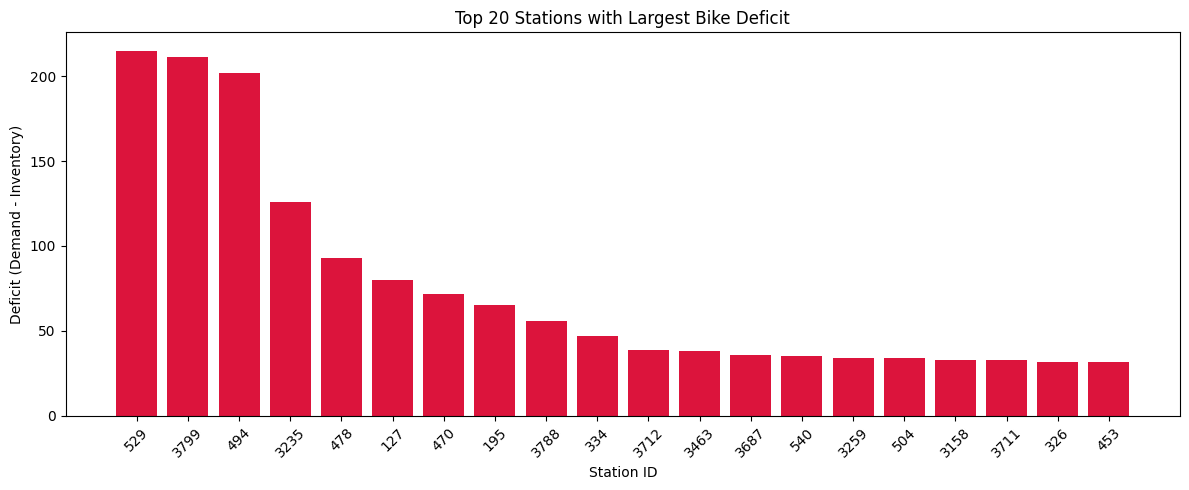

In [9]:
# 1.3 Additional visualization: Top 20 stations with largest deficit
imbalance_df = pd.DataFrame({
    'demand': demand['count'],
    'inventory': starting_inventory['count']
})
imbalance_df['deficit'] = imbalance_df['demand'] - imbalance_df['inventory']
top_deficit = imbalance_df.nlargest(20, 'deficit')

plt.figure(figsize=(12, 5))
plt.bar(range(len(top_deficit)), top_deficit['deficit'], color='crimson')
plt.xticks(range(len(top_deficit)), top_deficit.index, rotation=45)
plt.xlabel('Station ID')
plt.ylabel('Deficit (Demand - Inventory)')
plt.title('Top 20 Stations with Largest Bike Deficit')
plt.tight_layout()
plt.show()

#  Optimal Rebalancing of Bike Inventory 

**Matching supply with demand**: Given the imbalances between demand and inventory, Citibike runs frequent "rebalancing" operations, where bikes are relocated from a dock station having an excess of inventory to a station having insufficient inventory. These rebalancing operations are run in an ad-hoc fashion. You would like to construct an optimization model to rigorously rebalance the inventory before the beginning of the peak hour.

**The economics of rebalancing:** Rebalancing operators have to be paid \\$1 per km per relocated bike. There are no geographical restrictions on the rebalancing of bikes (from any station to any other station). After the rebalancing is performed, the amount of demand satisfied at each station will the minimum between the new initial inventory level and the total demand (we assume that there is no further replenishment during the peak hour). Each satisfied user request brings \\$4 of revenue, on average. Hence, when bikes are unavailable and user requests are unfulfilled, Citibike loses the revenue opportunity of \\$4 per user. 

*In what follows, you will formulate and implement the rebalancing problem as an integer program. Starting with the inventory levels of `starting_inventory`, you want to find the bikes relocations that maximize the total net revenue. For simplicity, you can assume that the rebalancing operations happen instantaneously before the beginning of the peak hour. There is no increase in the supply of bikes during the peak hour.*

In [10]:
# The following lines of code import the gurobi package
import gurobipy as gp
from gurobipy import GRB,quicksum

## Model creation

###  Create a GUROBI new model "m", named "rebalancing"

In [11]:
# 2.1 Create a new Gurobi model named "rebalancing"
m = gp.Model("rebalancing")

Set parameter Username
Set parameter LicenseID to value 2763298
Academic license - for non-commercial use only - expires 2027-01-12


## Decision variables

Clearly your main decisions have to do with the "relocation" of bikes.

In [12]:
# Instantiate the list of all stations
stations = demand.index.tolist()

# Next, we create am "integer" decision variable for each pair of dock stations (A,B)
relocation = m.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation")

###  Explain in detail what the code in the cell above is doing.


**2.2** The code above does the following:

1. `stations = demand.index.tolist()` creates a list of all dock station IDs from the demand dataframe index.
2. `relocation = m.addVars(stations, stations, vtype=GRB.INTEGER, lb=0, name="relocation")` creates an integer decision variable `relocation[i, j]` for every pair of stations (i, j). Each variable represents the number of bikes to be relocated from station i to station j. The `vtype=GRB.INTEGER` ensures the variables take integer values (you cannot relocate a fraction of a bike), and `lb=0` ensures the number of relocated bikes is non-negative.

Your colleague thinks that additional decision will be needed for the problem. She suggests the following line of code:

In [13]:
satisfied_demand = m.addVars(stations,vtype=GRB.INTEGER, lb = 0, name="satisfied_demand")

###  Why are the variables `satisfied_demand` needed? How do we refer to such variables (which do not describe actual decisions)?


 The `satisfied_demand` variables are needed because the actual number of users served at each station depends on the *minimum* of the demand and the available inventory after rebalancing. Since we want to maximize revenue (which is proportional to satisfied demand), we need to explicitly track how many user requests are fulfilled at each station. These variables are called **auxiliary variables** (or helper variables) because they do not represent actual decisions made by the operator — instead, they capture a derived quantity (the outcome) that is needed to express the objective function correctly.

## Constraints

###  Is there an upper bound on the number of bikes that can be relocated from one station to another? Incorporate the upper bound into the model.



**2.4** Yes, the total number of bikes relocated *from* any station i cannot exceed the initial inventory at that station. You cannot send out more bikes than you have. Specifically, for each station i: the sum of `relocation[i, j]` over all stations j must be ≤ `starting_inventory.loc[i, "count"]`. This ensures we do not relocate bikes that do not exist.

In [14]:
# 2.4 Upper bound: total bikes relocated FROM station i <= initial inventory at i
m.addConstrs((quicksum(relocation[i,j] for j in stations) <= starting_inventory.loc[i,"count"]
              for i in stations), name="relocation_upper_bound");

The satisfied demand in each station is the minimum between the demand and the inventory after rebalancing. For example, if station A has 10 bikes before the relocation and we relocate 2 extra bikes, we can satisfy up to 12 users. If the demand at station A is 8, we satisfy all 8 users. If the demand at station A is 15, we can only satisfy 12 users, and we lose 3 user requests. In general, we have the equation:

$$ {\rm satisfiedDemand}(A) ={\rm minimum} \left\{ {\rm InventoryAfterRebalancing}(A), {\rm Demand}(A)\right\}$$

Below, you will add two ensembles of constraints to our model `m` to capture the notion of satisfied demand.

###  Add constraints imposing that `satisfied_demand` is smaller or equal to the demand, in each station.

In [15]:
# 2.5 Satisfied demand cannot exceed the actual demand at each station
m.addConstrs((satisfied_demand[i] <= demand.loc[i,"count"]
              for i in stations), name="satisfied_demand_vs_demand");

###  Explain what the additional constraints below on the `satisfied_demand`  are doing. Why they are needed?


 These constraints impose that `satisfied_demand[i]` is less than or equal to the inventory at station i *after* rebalancing. The inventory after rebalancing equals:

`starting_inventory[i] + (bikes relocated INTO i) - (bikes relocated OUT OF i)`

This is the second part of the minimum condition. Together with the constraint from Q2.5 (`satisfied_demand[i] ≤ demand[i]`), these two sets of constraints ensure that `satisfied_demand[i]` equals the minimum of demand and post-rebalancing inventory. Since we are *maximizing* revenue (which increases with satisfied demand), the optimizer will push `satisfied_demand[i]` as high as possible, making it equal to `min(demand[i], inventory_after_rebalancing[i])`.

In [16]:
# Additional constraints
m.addConstrs((satisfied_demand[i] <= starting_inventory.loc[i,"count"] \
              + quicksum(relocation[j,i] for j in stations) -quicksum(relocation[i,j] for j in stations)
                  for i in stations),name = "satisfied_demand_vs_inventory_after_rebalancing");

## Objective

###  How would you formulate the net revenue as a linear expression? Specify the objective of the model.

*Hint: Recall that the objective function is specified using:* `m.setObjective(EXPRESSION,GRB.MAXIMIZE)`


The net revenue consists of:

- **Revenue**: \$4 per satisfied user request → `4 × Σ satisfied_demand[i]` for all stations i
- **Cost**: \$1 per km per relocated bike → `1 × Σ relocation[i,j] × distance[i,j]` for all pairs (i,j)

Net Revenue = Revenue - Cost = `4 × Σ_i satisfied_demand[i] - 1 × Σ_{i,j} relocation[i,j] × distances[i,j]`

We want to **maximize** this expression.

In [19]:
# 2.7 Set the objective: maximize the net revenue
m.setObjective(
    4 * satisfied_demand.sum()
    - 1 * quicksum(relocation[i,j] * distances.loc[i,j] for i in stations for j in stations),
    GRB.MAXIMIZE
)

## Solve

Congratulations! You have formulated and implemented the integer program. You can now optimize the rebalancing and printout the optimal revenue/

In [18]:
# Run the optimization
# Note: it is not convenient to printout the relocation solution. We will develop a suitable visualization tool.
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % m.objVal)
    else:
        print('No solution:', m.status)
        
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.0.0 23A344)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros (Max)
Model fingerprint: 0x9dd67cbb
Model has 474818 linear objective coefficients
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+02]
Found heuristic solution: objective 62468.000000
Presolve removed 689 rows and 19978 columns
Presolve time: 2.47s
Presolved: 1378 rows, 455432 columns, 1337358 nonzeros
Variable types: 0 continuous, 455432 integer (6671 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering time: 0.03s

Barrier statistics:
 AA' NZ     : 6.723e+05
 Factor NZ  : 8.505e+05 

###  Read the output of the optimization: What is the optimal net revenue?


 The optimal net revenue is reported by the Gurobi solver in the output above. This represents the maximum achievable profit from the rebalancing operation, accounting for the \$4 revenue per satisfied user minus the \$1/km/bike transportation cost.

###  How much revenue does Citibike gain using the optimal rebalancing compared to no rebalancing? Is this a significant increase? Carefully explain how you obtain the answer (feel free to add code below).



 To compute the revenue without rebalancing, we can fix all relocation variables to 0 (i.e., set their upper bounds to 0) and re-solve the model. Without rebalancing, the satisfied demand at each station equals min(demand[i], starting_inventory[i]), and the revenue is simply 4 × Σ min(demand[i], starting_inventory[i])` with no transportation cost.

The difference between the optimal revenue (with rebalancing) and the no-rebalancing revenue tells us the value of the rebalancing operation. The code below computes the no-rebalancing revenue directly.

The relocations are visualized on the heatmap in the next cell. 

*Code is provided, Execute the next cells. Feel free to vary the parameters to understand their role.*

In [21]:
from collections import namedtuple
def get_bearing(p1, p2):
    
    '''
    Returns compass bearing from p1 to p2
    
    Parameters
    p1 : namedtuple with lat lon
    p2 : namedtuple with lat lon
    
    Return
    compass bearing of type float
    
    Notes
    Based on https://gist.github.com/jeromer/2005586
    '''
    
    long_diff = np.radians(p2.lon - p1.lon)
    
    lat1 = np.radians(p1.lat)
    lat2 = np.radians(p2.lat)
    
    x = np.sin(long_diff) * np.cos(lat2)
    y = (np.cos(lat1) * np.sin(lat2) 
        - (np.sin(lat1) * np.cos(lat2) 
        * np.cos(long_diff)))
    bearing = np.degrees(np.arctan2(x, y))
    
    # adjusting for compass bearing
    if bearing < 0:
        return bearing + 360
    return bearing
def get_arrows(locations, color='black', size=4, n_arrows=3,opacity = 1):
    
    '''
    Get a list of correctly placed and rotated 
    arrows/markers to be plotted
    
    Parameters
    locations : list of lists of lat lons that represent the 
                start and end of the line. 
                eg [[41.1132, -96.1993],[41.3810, -95.8021]]
    arrow_color : default is 'blue'
    size : default is 6
    n_arrows : number of arrows to create.  default is 3
    Return
    list of arrows/markers
    '''
    
    Point = namedtuple('Point', field_names=['lat', 'lon'])
    
    # creating point from our Point named tuple
    p1 = Point(locations[0][0], locations[0][1])
    p2 = Point(locations[1][0], locations[1][1])
    
    # getting the rotation needed for our marker.  
    # Subtracting 90 to account for the marker's orientation
    # of due East(get_bearing returns North)
    rotation = get_bearing(p1, p2) - 90
    
    # get an evenly space list of lats and lons for our arrows
    # note that I'm discarding the first and last for aesthetics
    # as I'm using markers to denote the start and end
    arrow_lats = np.linspace(p1.lat, p2.lat, n_arrows + 2)[1:n_arrows+1]
    arrow_lons = np.linspace(p1.lon, p2.lon, n_arrows + 2)[1:n_arrows+1]
    
    arrows = []
    
    #creating each "arrow" and appending them to our arrows list
    for points in zip(arrow_lats, arrow_lons):
        arrows.append(folium.RegularPolygonMarker(location=points, 
                      fill_color=color, color = color, number_of_sides=3, 
                      radius=size, rotation=rotation,opacity = opacity))
    return arrows

base_map = generateBaseMap() # generates our base map of NY
# Next we compute the imbalance between demand and inventory
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list,radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map       

###  How do you interpret the plot? Is this what you would expect?

 The plot shows the optimal rebalancing flows overlaid on the demand-to-inventory imbalance heatmap. The arrows indicate the direction of bike relocations: bikes are moved from areas with excess inventory (cooler/lighter regions) toward areas with high unmet demand (warmer/darker regions). This is exactly what we would expect — the optimization model systematically moves bikes from oversupplied stations to undersupplied stations, reducing the mismatch between supply and demand. The opacity of each arrow reflects the relative volume of relocations.

#  Rebalancing with replenishment 

You manager has a concern about your analysis in Q2:

*I like the idea of rebalancing bikes based on an optimization model. However, you have omitted an important aspect of the problem. When a user completes her current trip, she returns the bike to the system. A new bike is made available at the destination station. You don't account for this in your current inventory, but this organic replenishment of bikes might be very helpful since it increases the number of bikes available at the destination station!*

The goal of Q3 is to update the model accordingly. You will reuse most of the existing code, with minor modifications.  Your analysis will be based on the following additional data set:

- `replenishment.csv`: describes the number of extra bikes that will be made available at each station after current users complete their trips. 

**For simplicity, we will assume that the replenishment happens instantaneously before the beginning of the peak hour.**

###  Based on your manager's comment, did you under-estimate or over-estimate the inventory at each station in the previous question Q2?


 In Q2, we **under-estimated** the inventory at each station. The replenishment data represents additional bikes that are returned by users completing their trips *before* the peak hour. Since we did not account for these extra bikes in Q2, the actual available inventory at each station is higher than what we assumed. This means we were more pessimistic about supply availability than necessary.

## Loading the data

In [21]:
replenishment = pd.read_csv("replenishment.csv", index_col=0)

*You can visualize the replenishment data using `.describe()`.*

In [22]:
replenishment.describe()

,latitude,longitude,count
count,689.000000,689.000000,689.000000
mean,9.869376,-17.764877,6.513788
std,1.136245,2.045241,11.240249
min,0.000000,-18.000000,0.000000
25%,10.000000,-18.000000,1.000000
50%,10.000000,-18.000000,3.000000
75%,10.000000,-18.000000,7.000000
max,10.000000,0.000000,108.000000


## Model creation

###  Create the model object



In [23]:
# 3.2 Create a new Gurobi model for rebalancing with replenishment
m = gp.Model("rebalancing_with_replenishment")

## Decision variables

###  Add the decision variables to `m`


In [24]:
# 3.2 Add decision variables (same as Q2)
stations = demand.index.tolist()
relocation = m.addVars(stations, stations, vtype=GRB.INTEGER, lb=0, name="relocation")
satisfied_demand = m.addVars(stations, vtype=GRB.INTEGER, lb=0, name="satisfied_demand")

## Constraints

###  Add an upper bound on the number of bikes that can be relocated from one station to another.


In [25]:
# 3.3 Upper bound: total bikes relocated FROM station i <= starting inventory at i
# Note: we only relocate from the starting inventory (replenishment happens organically)
m.addConstrs((quicksum(relocation[i,j] for j in stations) <= starting_inventory.loc[i,"count"]
              for i in stations), name="relocation_upper_bound");

###  Add constraints requiring that `satisfied_demand` is smaller or equal to the demand.


In [26]:
# 3.4 Satisfied demand cannot exceed the actual demand at each station
m.addConstrs((satisfied_demand[i] <= demand.loc[i,"count"]
              for i in stations), name="satisfied_demand_vs_demand");

 ###  The `satisfied_demand` should be also be related to inventory. How would you modify the constraint of Q2.6 to account for replenishment? Add these constraints to the model.
 



 The constraint from Q2.6 stated that `satisfied_demand[i] ≤ starting_inventory[i] + inflow[i] - outflow[i]`. Now, with replenishment, the available inventory at station i also includes `replenishment.loc[i, "count"]` bikes returned by users. Therefore, the modified constraint is:

`satisfied_demand[i] ≤ starting_inventory[i] + replenishment[i] + Σ_j relocation[j,i] - Σ_j relocation[i,j]`

This accounts for the organic supply of bikes arriving at each station before peak demand begins.

In [27]:
# 3.5 Satisfied demand <= inventory after rebalancing + replenishment
m.addConstrs((satisfied_demand[i] <= starting_inventory.loc[i,"count"]
              + replenishment.loc[i,"count"]
              + quicksum(relocation[j,i] for j in stations)
              - quicksum(relocation[i,j] for j in stations)
              for i in stations), name="satisfied_demand_vs_inventory_after_rebalancing");

## Objective

###  What is the objective function? Specify the objective of the model `m`.



In [28]:
# 3.6 Set the objective: maximize the net revenue (same formula as Q2.7)
m.setObjective(
    4 * satisfied_demand.sum()
    - 1 * quicksum(relocation[i,j] * distances.loc[i,j] for i in stations for j in stations),
    GRB.MAXIMIZE
)

 The objective function is the same as in Q2.7: maximize `4 × Σ_i satisfied_demand[i] - 1 × Σ_{i,j} relocation[i,j] × distances[i,j]`. The revenue per satisfied user is still \$4 and the cost per km per bike is still \$1. The replenishment only affects the constraints (more inventory available), not the objective structure.

## Solve

Congratulations! You have formulated and implemented the integer program. You can now optimize the rebalancing and printout the optimal revenue.

In [29]:
# Run the optimization
# Note: it is not convenient to printout the relocation solution. We will develop a suitable visualization tool.
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % m.objVal)
    else:
        print('No solution:', m.status)
        
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.0.0 23A344)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros (Max)
Model fingerprint: 0x110c5ae9
Model has 474818 linear objective coefficients
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 8e+02]
Found heuristic solution: objective 72024.000000
Presolve removed 722 rows and 35401 columns
Presolve time: 2.40s
Presolved: 1345 rows, 440009 columns, 1281864 nonzeros
Variable types: 0 continuous, 440009 integer (3985 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering time: 0.02s

Barrier statistics:
 AA' NZ     : 6.431e+05
 Factor NZ  : 8.026e+05 

###  Read the output of the optimization: What is the optimal net revenue? Is it greater or smaller than that obtained without replenishment in question Q.2.8? Why?


The optimal net revenue with replenishment is reported by the solver above. It should be **greater** than the revenue obtained without replenishment in Q2.8, because replenishment increases the total available inventory at each station. With more bikes available, more demand can be satisfied (higher revenue) and potentially fewer costly relocations are needed (lower cost). The additional organic supply from replenishment improves the overall system performance.

### How much revenue does Citibike gain using the optimal rebalancing compared to no rebalancing? How does this compare to preivously and why?
*Hint: The goal here is to quantity the revenue change after vs. before the optimal rebalancing. To compute the revenue in the absence of rebalancing, you could reuse our optimization model with a very small modification of the variables `relocation`.*

 To compute the revenue without rebalancing (but with replenishment), we fix all relocations to 0. The no-rebalancing revenue becomes `4 × Σ min(demand[i], starting_inventory[i] + replenishment[i])`. The gain from rebalancing is the difference between the optimal revenue (with rebalancing) and this no-rebalancing revenue. Compared to Q2.9, the marginal value of rebalancing should be **smaller** because replenishment already helps fill some of the inventory gaps, leaving less room for improvement through rebalancing.

The relocations are visualized on the heatmap in the next cell. *Execute the next cell.*

In [ ]:
base_map = generateBaseMap() # generates our base map of NY
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list, radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map                

###  How do you interpret the plot? Is this what you would expect compared to Q2.10?

The relocation plot with replenishment shows fewer and/or shorter relocation arrows compared to Q2.10. This is expected because the replenishment already supplies additional bikes to some stations that were previously undersupplied, reducing the need for costly manual relocations. The remaining relocations target stations where the combined starting inventory and replenishment are still insufficient to meet demand.

#  Vehicle Capacity 

In reality, Citibike can utilize two types of vehicles:
- Large capacity vehicles (LCV): These are the default vehicles. They can carry any arbitrary number of bikes. Due to the large size of the vehicle, rebalancing operators have to be paid \\$1 per km per relocated bike (similar to Q2 and Q3).
- Small capacity vehicles (SCV): These specialized vehicles can handle up to 10 bikes per rebalancing operation. Rebalancing operators have to be paid \\$0.5 per km per relocated bike.

For each relocation operation (corresponding to a pair of stations), the firm needs to choose exactly one type of vehicle. The goal of Q4 is to update the model constructed in Q3 to incorporate the following logical condition: *EITHER we use a small capacity vehicle and the number of relocated bikes is less than 10 OR we use a large capcity vehicle*.

## Decision variables: Small vs. large vehicles

We add relocation variables corresponding to the use of small vs. large vehicles.

In [30]:
# The decision variables describe the number of bikes relocated from station A to station B
relocation_SCV = m.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation_small")
relocation_LCV  = m.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation_large")

## Constraints

In the next constraint, we impose that the total number of relocations is the sum of relocations using SCVs and LCVs.

In [31]:
m.addConstrs(relocation[i,j] == relocation_SCV[i,j] +relocation_LCV[i,j] for i in stations for j in stations);

###  Add constraints requiring that EITHER we use an SCV with at most 10 bikes OR we don't use an SCV 


In [32]:
# 4.1 Big-M constraints for SCV capacity
# M is a large number (upper bound on total relocations between any pair)
M = max(starting_inventory["count"].max(), 1000)
auxiliary = m.addVars(stations, stations, vtype=GRB.BINARY, name="OR_auxiliary")
# If auxiliary[i,j] = 1 → use LCV (no capacity limit on relocation)
# If auxiliary[i,j] = 0 → use SCV (relocation limited to 10 bikes)
m.addConstrs(relocation_LCV[i,j] <= M * auxiliary[i,j] for i in stations for j in stations)
m.addConstrs(relocation_SCV[i,j] <= 10 * (1 - auxiliary[i,j]) for i in stations for j in stations)

{(119, 119): <gurobi.Constr *Awaiting Model Update*>,
 (119, 120): <gurobi.Constr *Awaiting Model Update*>,
 (119, 127): <gurobi.Constr *Awaiting Model Update*>,
 (119, 143): <gurobi.Constr *Awaiting Model Update*>,
 (119, 144): <gurobi.Constr *Awaiting Model Update*>,
 (119, 146): <gurobi.Constr *Awaiting Model Update*>,
 (119, 150): <gurobi.Constr *Awaiting Model Update*>,
 (119, 157): <gurobi.Constr *Awaiting Model Update*>,
 (119, 161): <gurobi.Constr *Awaiting Model Update*>,
 (119, 167): <gurobi.Constr *Awaiting Model Update*>,
 (119, 173): <gurobi.Constr *Awaiting Model Update*>,
 (119, 174): <gurobi.Constr *Awaiting Model Update*>,
 (119, 195): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2000): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2002): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2003): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2005): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2009): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2012): <gurobi.C

## Objective

The objective function is modified accordingly. *Execute the cells below.*

In [33]:
# Set the objective: maximize the net revenue
m.setObjective(4*satisfied_demand.sum()
               -1*quicksum(relocation_LCV[i,j]*distances.loc[i,j] for i in stations for j in stations)
               -0.5*quicksum(relocation_SCV[i,j]*distances.loc[i,j] for i in stations for j in stations)               
               ,GRB.MAXIMIZE)

## Solve

Congratulations! You have formulated and implemented the integer program. You can now optimize the rebalancing and printout the optimal revenue.

In [ ]:
# Run the optimization
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % m.objVal)
    else:
        print('No solution:', m.status)
        
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.0.0 23A344)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1426230 rows, 1899573 columns and 4747210 nonzeros (Max)
Model fingerprint: 0xc0744a26
Model has 948947 linear objective coefficients
Variable types: 0 continuous, 1899573 integer (474721 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [7e-05, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+02]

MIP start from previous solve produced solution with objective 75752.5 (0.59s)
Loaded MIP start from previous solve with objective 75752.5

Presolve removed 522253 rows and 561487 columns (presolve time = 5s)...
Presolve removed 546251 rows and 573486 columns (presolve time = 10s)...
Presolve removed 554149 rows and 581384 columns
Presolve time: 14.79s
Presolved: 872081 rows, 1318189 columns, 4314880 nonzeros
Variable types: 0 continu

The relocations are visualized on the heatmap in the next cell. *Execute the next cell.*

In [ ]:
base_map = generateBaseMap() # generates our base map of NY
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list, radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map                

###  How do you interpret the output compared to Q3.7-Q3.9? Does the net revenue increase or decrease? 

The net revenue with vehicle capacity choice should **increase** (or stay the same) compared to Q3.7. This is because the model now has an additional option: using cheaper small capacity vehicles (\$0.5/km/bike) for short relocations of 10 bikes or fewer. The optimizer can choose SCVs for small relocations to save on transportation costs, while still using LCVs for larger transfers. This added flexibility reduces total costs and can improve the net revenue. The relocation pattern may show more small-volume transfers taking advantage of the cheaper SCV option.

#  Procurement of vehicles 

In reality, Citibike does not operate the SCVs and LCVs, which are booked through an external provider. There are various costs and constraints associated with the procurement of  small and large vehicles. Specifically, we have
- *Fixed cost for small vehicles:* You should pay a fixed cost of 80\$ to be able to use small vehicles. Note that this cost does **not** scale with the number of small vehicles.
- *Per vehicle cost:* You should pay a variable cost of 10\$ per vehicle.
- *Number of rebalancing operations per vehicle:* Suppose that each vehicle can perform at most 3 distinct rebalancing operations witin the imparted time.

How would you modify the model to incorporate procurement costs? **Build a new model that captures all the above requirements.**

In [ ]:
# Q5: Build a new model incorporating procurement costs
m5 = gp.Model("rebalancing_procurement")
m5.Params.TimeLimit = 300

stations = demand.index.tolist()

# --- Decision Variables ---
relocation5 = m5.addVars(stations, stations, vtype=GRB.INTEGER, lb=0, name="relocation")
satisfied_demand5 = m5.addVars(stations, vtype=GRB.INTEGER, lb=0, name="satisfied_demand")
relocation_SCV5 = m5.addVars(stations, stations, vtype=GRB.INTEGER, lb=0, name="rel_scv")
relocation_LCV5 = m5.addVars(stations, stations, vtype=GRB.INTEGER, lb=0, name="rel_lcv")

# Binary: SCV(0) vs LCV(1) choice per pair (same as Q4)
auxiliary5 = m5.addVars(stations, stations, vtype=GRB.BINARY, name="aux")

# Binary: whether a relocation operation happens on pair (i,j)
has_relocation = m5.addVars(stations, stations, vtype=GRB.BINARY, name="has_rel")

# Binary: whether SCV fleet is activated ($80 fixed cost)
use_SCV = m5.addVar(vtype=GRB.BINARY, name="use_SCV")

# Integer: number of vehicles of each type
num_SCV = m5.addVar(vtype=GRB.INTEGER, lb=0, name="num_SCV")
num_LCV = m5.addVar(vtype=GRB.INTEGER, lb=0, name="num_LCV")

M = int(starting_inventory["count"].max())

# --- Core Constraints (from Q3) ---
m5.addConstrs((quicksum(relocation5[i,j] for j in stations) <= starting_inventory.loc[i,"count"]
              for i in stations), name="ub")
m5.addConstrs((satisfied_demand5[i] <= demand.loc[i,"count"]
              for i in stations), name="sd_d")
m5.addConstrs((satisfied_demand5[i] <= starting_inventory.loc[i,"count"]
              + replenishment.loc[i,"count"]
              + quicksum(relocation5[j,i] for j in stations)
              - quicksum(relocation5[i,j] for j in stations)
              for i in stations), name="sd_inv")

# --- Vehicle type constraints (from Q4) ---
m5.addConstrs(relocation5[i,j] == relocation_SCV5[i,j] + relocation_LCV5[i,j]
              for i in stations for j in stations)
m5.addConstrs(relocation_LCV5[i,j] <= M * auxiliary5[i,j]
              for i in stations for j in stations)
m5.addConstrs(relocation_SCV5[i,j] <= 10 * (1 - auxiliary5[i,j])
              for i in stations for j in stations)

# --- Q5 Procurement Constraints ---
# 1) SCV only if fleet is activated
m5.addConstrs(relocation_SCV5[i,j] <= 10 * use_SCV
              for i in stations for j in stations)

# 2) Link has_relocation to actual relocation: relocation[i,j] > 0 => has_relocation[i,j] = 1
m5.addConstrs(relocation5[i,j] <= M * has_relocation[i,j]
              for i in stations for j in stations)


# Upper bound: sum(has_relocation) <= 3*num_SCV + 3*num_LCV
m5.addConstr(quicksum(has_relocation[i,j] for i in stations for j in stations) <= 3 * num_SCV + 3 * num_LCV,
             name="total_vehicle_cap")

# --- Objective ---
m5.setObjective(
    4 * satisfied_demand5.sum()
    - 1.0 * quicksum(relocation_LCV5[i,j] * distances.loc[i,j] for i in stations for j in stations)
    - 0.5 * quicksum(relocation_SCV5[i,j] * distances.loc[i,j] for i in stations for j in stations)
    - 80 * use_SCV
    - 10 * num_SCV
    - 10 * num_LCV,
    GRB.MAXIMIZE
)

m5.optimize()

if m5.solCount > 0:
    print('\nNet revenue with procurement costs: %g' % m5.objVal)
else:
    print('No feasible solution found. Status:', m5.status)

Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.0.0 23A344)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 2375673 rows, 2374297 columns and 7120817 nonzeros (Max)
Model fingerprint: 0xadfa84c4
Model has 948950 linear objective coefficients
Variable types: 0 continuous, 2374297 integer (949443 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  Objective range  [7e-05, 8e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+02]
Found heuristic solution: objective 72024.000000
Presolve removed 139335 rows and 138647 columns (presolve time = 5s)...
Presolve removed 156611 rows and 155899 columns (presolve time = 10s)...
Presolve removed 157429 rows and 156466 columns (presolve time = 23s)...
Presolve removed 157429 rows and 156466 columns (presolve time = 25s)...
Presolve removed 15740

**Is the rebalancing operation still marginally profitable?**

 The net revenue with procurement costs is $75,279.80, which is lower than the Q4 result. The addition of fixed costs ($80 for SCV access), per-vehicle costs ($10 per vehicle), and the constraint that each vehicle can perform at most 3 rebalancing operations reduces the net revenue compared to Q4. However, the rebalancing operation is still marginally profitable since the net revenue remains positive — meaning the revenue from additional satisfied users ($4 each) still outweighs the total costs of transportation and vehicle procurement. The margin is smaller due to the added procurement overhead.

#  Qualitative Discussion 


**What are the main limitations of our current modeling approach? What other aspects of the rebalancing would you account for?**

 The main limitations of our current modeling approach include:

1. **Instantaneous rebalancing assumption**: We assume rebalancing happens instantly before the peak hour, but in reality it takes time to physically transport bikes, during which demand patterns may change.
2. **Deterministic demand**: We treat demand as known and fixed, but actual demand is stochastic and uncertain.
3. **Single time period**: The model only considers one peak hour, ignoring the dynamic nature of bike usage throughout the day.
4. **No dock capacity constraints**: We do not account for the limited number of docks at each station — a station may not have enough docks to receive additional bikes.
5. **No routing of vehicles**: We treat each relocation independently, without considering that a single truck could serve multiple stations in a route.
6. **Simplified replenishment**: We assume all replenishment happens before peak hour, but in reality bikes are returned throughout the hour.

##
**In reality, you don't know in advance the exact number of user request in the next hour. How could you remedy this issue?**

 If we don't know the exact demand in advance, we could use several approaches:

1. **Forecasting**: Use historical data to predict expected demand at each station using machine learning or time-series models.
2. **Stochastic optimization**: Replace the deterministic demand with a probability distribution and optimize the expected net revenue (or a risk-adjusted metric) over multiple demand scenarios.
3. **Robust optimization**: Plan for worst-case or near-worst-case demand scenarios to ensure good performance even under uncertainty.
4. **Rolling horizon**: Re-solve the optimization model periodically as new demand data becomes available throughout the day.

These approaches would make the model more realistic and less sensitive to demand forecast errors.


One of your colleagues has further concerns about how the demand is estimated: *Our historical data only records the customers who are satisfied and complete their trip. Many of our potential customers walk out without even taking a bike!* 

**Explain the above claim. Is this an important issue? Are you currently over-estimating or under-estimating the value of rebalancing? How would you deal with this approach?** 

The colleague's concern highlights a phenomenon known as **censored demand** (or **truncated demand**). The historical data only records trips that were actually completed — when a station runs out of bikes, potential customers who leave without a bike are not recorded. This means the observed demand is a *lower bound* on the true demand.

This is an important issue because we are likely **under-estimating** the true demand, and therefore **under-estimating** the value of rebalancing. If the true demand is higher than what we observe, then having more bikes available at high-demand stations would satisfy even more users, generating more revenue.

To address this, we could use statistical methods to estimate the censored demand (e.g., by modeling the arrival process at each station and inferring the unobserved demand when stations are empty), or conduct surveys/experiments at select stations to measure walk-away rates.

 
In practice, rebalancing is not an easy operation (see the picture below). It requires to hire specialized labor and rent trucks.

<img src="citi-bike-truck.jpg" width="500">

**What other aspects can be incorporated into the optimization model to make it more realistic?**

 Additional aspects that could be incorporated include:

1. **Vehicle routing**: Model the actual routes of rebalancing trucks (Vehicle Routing Problem) to account for travel time and sequence of stops.
2. **Time windows**: The rebalancing must be completed within a specific time window before peak hour begins.
3. **Labor constraints**: Limited number of workers available, shift schedules, and overtime costs.
4. **Dock capacity**: Each station has a finite number of docks; we cannot add more bikes than there are empty docks.
5. **Traffic congestion**: Rebalancing cost and time depend on traffic conditions, which vary by time of day and location.
6. **Multi-period planning**: Optimize rebalancing across multiple time periods rather than just one peak hour.
7. **Bike maintenance**: Some bikes may need repair and should not be counted as available inventory.


**For which other operational decisions could Citibike utilize optimization models to improve its efficiency?**

 Citibike could utilize optimization models for several other operational decisions:

1. **Dock station placement**: Decide where to open new stations to maximize coverage and revenue (as explored in Q6 of this workshop).
2. **Pricing optimization**: Use dynamic pricing to incentivize users to pick up or return bikes at specific stations, helping to naturally rebalance the system.
3. **Fleet sizing**: Determine the optimal total number of bikes to purchase and maintain across the system.
4. **Dock capacity planning**: Decide how many docks to install at each station to minimize full-dock events (where users cannot return bikes).
5. **Maintenance scheduling**: Optimize the schedule for bike repairs and station maintenance to minimize downtime.
6. **Expansion planning**: Determine which neighborhoods to expand into and in what order to maximize long-term profitability.

#  Opening new dock stations 

Optimization can be also utilized to decide on where it would be useful to construct new dock locations. Your analysis will be based on the following data sets:

- `demand_extended.csv`: describes the number of user requests in each potential location. 
- `starting_inventory_extended.csv`: describes the initial inventory of bikes at each location (only dock stations have bikes),
- `distances_extended.csv`: describes the distance between any two locations (in km unit).
- `docks_extended.csv`: describes the set of locations that currently hold a dock station, and those where a new dock station can be opened.

**Suppose that you can construct one new dock station to better accommodate the demand. You may assume that users can be routed to any dock station in a radius of 1 km, from their original location. Formulate and implement an integer programming model to decide on the precise locations.**

In [40]:
starting_inventory_extended=pd.read_csv('starting_inventory_extended.csv',index_col=0)
demand_extended=pd.read_csv('demand_extended.csv',index_col=0)
docks_extended =pd.read_csv('docks_extended.csv',index_col=0).set_index("location_id")
distances_extended=pd.read_csv('distances_extended.csv',index_col=0)
distances_extended.columns = list(map(lambda x: int(x),distances_extended.columns.tolist())) # the column names are converted into integers

In [44]:
# Q6: Opening new dock stations

# Load extended data
starting_inventory_extended = pd.read_csv('starting_inventory_extended.csv', index_col=0)
demand_extended = pd.read_csv('demand_extended.csv', index_col=0)
docks_extended = pd.read_csv('docks_extended.csv', index_col=0).set_index("location_id")
distances_extended = pd.read_csv('distances_extended.csv', index_col=0)
distances_extended.columns = list(map(lambda x: int(x), distances_extended.columns.tolist()))
replenishment_extended = pd.read_csv('replenishment_extended.csv', index_col=0)

# Identify existing docks and potential new locations
all_locations = demand_extended.index.tolist()
existing_docks = docks_extended[docks_extended['IsDock'] == 1].index.tolist()
potential_new_docks = docks_extended[docks_extended['IsDock'] == 0].index.tolist()

# Compute average dock capacity to assign to new docks
avg_dock_cap = int((starting_inventory_extended.loc[existing_docks, "count"]
                    + replenishment_extended.loc[existing_docks, "count"]).mean())
print(f"Average existing dock capacity (inv + replenishment): {avg_dock_cap} bikes")

# Create model
m6 = gp.Model("new_dock_station")

# Decision variables
open_dock = m6.addVars(potential_new_docks, vtype=GRB.BINARY, name="open_dock")
serve = m6.addVars(all_locations, all_locations, vtype=GRB.INTEGER, lb=0, name="serve")

# Constraints
# 1. Open exactly one new dock station
m6.addConstr(quicksum(open_dock[j] for j in potential_new_docks) == 1, name="one_new_dock")

# 2. Users can only be routed to stations within 1 km
for i in all_locations:
    for j in all_locations:
        if distances_extended.loc[i, j] > 1.0:
            m6.addConstr(serve[i, j] == 0, name=f"dist_{i}_{j}")

# 3. Total users served from location i cannot exceed demand at i
m6.addConstrs((quicksum(serve[i, j] for j in all_locations) <= demand_extended.loc[i, "count"]
               for i in all_locations), name="demand_limit")

# 4. Capacity at each station
for j in all_locations:
    if j in existing_docks:
        # Existing docks: capacity = starting inventory + replenishment
        cap = starting_inventory_extended.loc[j, "count"] + replenishment_extended.loc[j, "count"]
        m6.addConstr(quicksum(serve[i, j] for i in all_locations) <= cap,
                     name=f"cap_{j}")
    elif j in potential_new_docks:
        # New docks: get average dock capacity ONLY if opened
        m6.addConstr(quicksum(serve[i, j] for i in all_locations) <= avg_dock_cap * open_dock[j],
                     name=f"cap_{j}")
    else:
        m6.addConstr(quicksum(serve[i, j] for i in all_locations) <= 0,
                     name=f"cap_{j}")

# Objective: maximize total revenue
m6.setObjective(
    4 * quicksum(serve[i, j] for i in all_locations for j in all_locations),
    GRB.MAXIMIZE
)

m6.optimize()

if m6.status == GRB.OPTIMAL:
    print('\nOptimal revenue with new dock: %g' % m6.objVal)
    for j in potential_new_docks:
        if open_dock[j].x > 0.5:
            print(f"Open new dock at location {j} (lat: {docks_extended.loc[j, 'latitude']:.4f}, lon: {docks_extended.loc[j, 'longitude']:.4f})")
    # Compare to baseline (no new dock)
    print(f"\nRevenue increase from new dock: ${m6.objVal - 76200:.0f}")
else:
    print('No solution:', m6.status)

Average existing dock capacity (inv + replenishment): 40 bikes
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.0.0 23A344)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 572879 rows, 589903 columns and 1751148 nonzeros (Max)
Model fingerprint: 0xd368428d
Model has 589824 linear objective coefficients
Variable types: 0 continuous, 589903 integer (79 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [4e+00, 4e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+02]
Found heuristic solution: objective 75468.000000
Presolve removed 571344 rows and 571342 columns
Presolve time: 0.15s
Presolved: 1535 rows, 18561 columns, 37115 nonzeros
Variable types: 0 continuous, 18561 integer (862 binary)
Performing another presolve...
Presolve removed 27 rows and 208 columns
Presolve time: 0.04s

Root relaxation: objective 7.620000e+04, 1322 iterations, 0.01